In [1]:
import pandas as pd
import numpy as np

# 1. Préparation des données
df = pd.read_csv('social_media_productivity_6000.csv').dropna()

# y est notre vecteur cible (Productivité)
y = df['productivity_score'].values

# X_raw contient nos variables (Étude, Réseaux, Sommeil)
X_raw = df[['study_hours', 'social_media_hours', 'sleep_hours']].values

# 2. AJOUT DE LA COLONNE DE BIAIS (La colonne de 1)
# Pour que le calcul matriciel trouve l'interception (b), on ajoute une colonne de 1
biases = np.ones((X_raw.shape[0], 1)) # crée une nouvelle colonne remplie uniquement du chiffre 1
X = np.append(biases, X_raw, axis=1) # On colle cette colonne de 1juste avant tes données de Heures d'étude, Réseaux et Sommeil

# 3. LE CALCUL MATRICIEL (L'Équation Normale)
# Étape A: Transposée de X
XT = X.T

# Étape B: Multiplication de la transposée par X
XTX = np.dot(XT, X)

# Étape C: Inversion de la matrice résultante
XTX_inv = np.linalg.inv(XTX)

# Étape D: Multiplication par la transposée de X et par y
XTy = np.dot(XT, y)
B = np.dot(XTX_inv, XTy)

# 4. RÉSULTATS
intercept = B[0]
coeff_etude = B[1]
coeff_reseaux = B[2]
coeff_sommeil = B[3]

print(f"Interception (b) : {intercept:.4f}")
print(f"Pente Étude (a1) : {coeff_etude:.4f}")
print(f"Pente Réseaux (a2) : {coeff_reseaux:.4f}")
print(f"Pente Sommeil (a3) : {coeff_sommeil:.4f}")

# 5. PRÉDICTION ET PERFORMANCE
y_pred = np.dot(X, B) # y_pred contient les scores de productivité
ss_res = np.sum((y - y_pred)**2) # la Somme des Carré
ss_tot = np.sum((y - np.mean(y))**2)# la Somme Totale des Carrés
r2 = 1 - (ss_res / ss_tot)# calcul du Coefficient de Détermination 

print(f"Score R² : {r2:.4f}")

Interception (b) : 1.1752
Pente Étude (a1) : 8.8250
Pente Réseaux (a2) : -6.5231
Pente Sommeil (a3) : 4.2445
Score R² : 0.8528


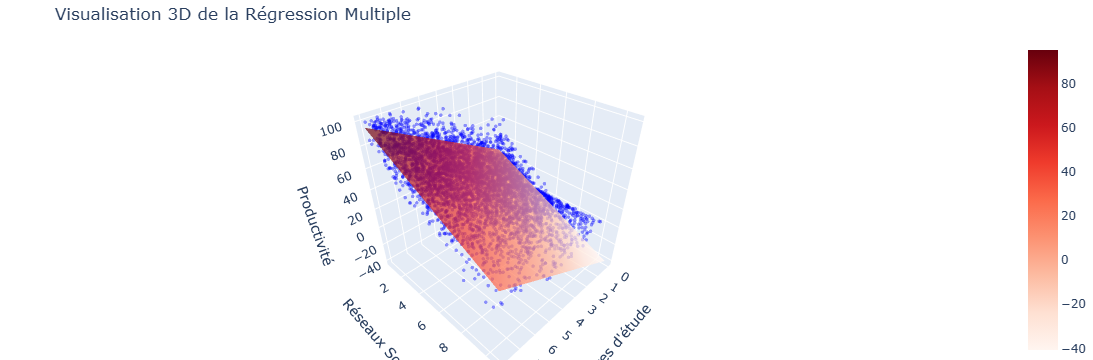

In [2]:
import plotly.graph_objects as go
import numpy as np

# 1. Création d'une grille de points pour la surface
# On crée 20 points allant du min au max pour chaque axe
x_range = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 20)
y_range = np.linspace(df['social_media_hours'].min(), df['social_media_hours'].max(), 20)
x_grid, y_grid = np.meshgrid(x_range, y_range)

# 2. Calcul des prédictions sur toute la grille
# On utilise nos coefficients calculés manuellement (B)
# On fixe le sommeil à sa moyenne pour la visualisation
sleep_mean = df['sleep_hours'].mean()

# Formule : z = b + (a1 * étude) + (a2 * réseaux) + (a3 * sommeil_moyen)
z_grid = B[0] + (B[1] * x_grid) + (B[2] * y_grid) + (B[3] * sleep_mean)

# 3. Création de la figure 3D
fig = go.Figure(data=[
    # Le nuage de points réels (en bleu)
    go.Scatter3d(
        x=df['study_hours'], 
        y=df['social_media_hours'], 
        z=df['productivity_score'],
        mode='markers',
        marker=dict(size=2, opacity=0.4, color='blue'),
        name='Données Réelles'
    ),
    # Le plan de prédiction (la surface rouge)
    go.Surface(
        x=x_range, 
        y=y_range, 
        z=z_grid, 
        opacity=0.7, 
        colorscale='Reds',
        name='Plan de Régression'
    )
])

# 4. Habillage du graphique
fig.update_layout(
    title='Visualisation 3D de la Régression Multiple',
    scene=dict(
        xaxis_title='Heures d\'étude',
        yaxis_title='Réseaux Sociaux',
        zaxis_title='Productivité'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()